# ADSR Envelope Generator

An ADSR envelope shapes amplitude over four segments: **Attack**, **Decay**, **Sustain**, and **Release**.

```
1.0 ─────┐
         │\
sustain ─│ ─────────────────┐
         │                   \
0.0 ─────────────────────────────
         A    D        S      R
```

| Parameter | Type | Description |
| --- | --- | --- |
| `attack` | seconds | Rise time from 0 to 1.0 |
| `decay` | seconds | Fall from 1.0 to `sustain` |
| `sustain` | 0–1 | Level held until release |
| `release` | seconds | Fall from `sustain` to 0.0 |
| `curve` | `"linear"` / `"exponential"` | Shape of decay and release segments |

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_adsr, generate_sine

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Four Classic ADSR Shapes

Common envelope shapes used in synthesis: fast pluck, slow pad, long-decay percussion, and a lead with sustain.

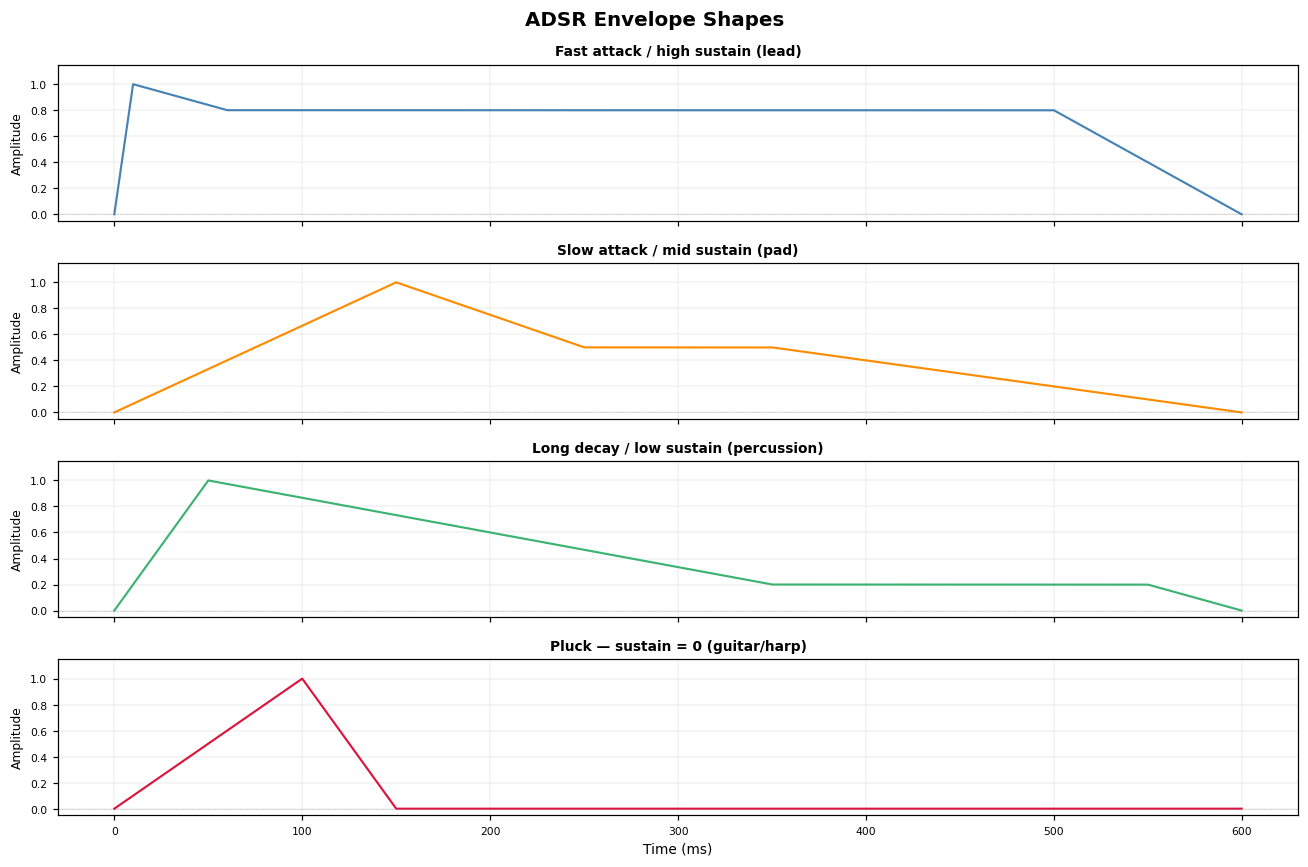

In [2]:
DURATION = 0.6

SHAPES = [
    dict(attack=0.01, decay=0.05, sustain=0.8, release=0.10, label='Fast attack / high sustain (lead)'),
    dict(attack=0.15, decay=0.10, sustain=0.5, release=0.25, label='Slow attack / mid sustain (pad)'),
    dict(attack=0.05, decay=0.30, sustain=0.2, release=0.05, label='Long decay / low sustain (percussion)'),
    dict(attack=0.10, decay=0.05, sustain=0.0, release=0.20, label='Pluck — sustain = 0 (guitar/harp)'),
]

colors = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']
fig, axes = plt.subplots(len(SHAPES), 1, figsize=(12, 8), sharex=True)

for ax, shape, color in zip(axes, SHAPES, colors):
    kw = {k: v for k, v in shape.items() if k != 'label'}
    t, env = generate_adsr(fs=FS, duration=DURATION, **kw)
    ax.plot(t * 1000, env, color=color, linewidth=1.4)
    ax.set_title(shape['label'], fontsize=9, fontweight='bold')
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.set_ylim(-0.05, 1.15)
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)
    ax.axhline(0, color='gray', linewidth=0.4, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Time (ms)', fontsize=9)
fig.suptitle('ADSR Envelope Shapes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Linear vs Exponential Curves

With `curve="exponential"`, the decay and release segments use a normalized `(1 − e^{−kt})` curve that still hits both endpoints exactly. The exponential shape falls faster at the start and slower at the tail — closer to the natural decay of an RC circuit.

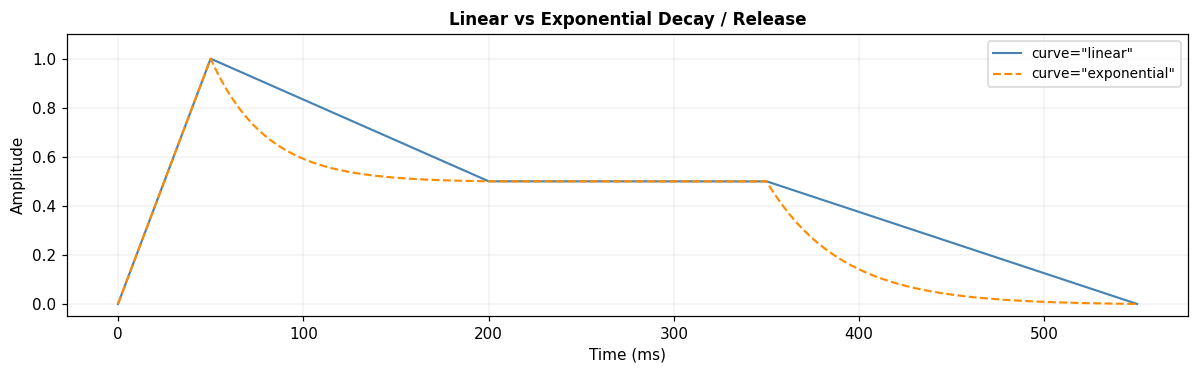

Attack peak   — linear: 1.000000, exponential: 1.000000
Release end   — linear: 0.000000,   exponential: 0.000000
Decay end     — linear: 0.500000, exponential: 0.500000 (sustain=0.5)


In [3]:
kw = dict(attack=0.05, decay=0.15, sustain=0.5, release=0.20, fs=FS, duration=0.55)

t_lin, env_lin = generate_adsr(**kw, curve='linear')
t_exp, env_exp = generate_adsr(**kw, curve='exponential')

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t_lin * 1000, env_lin, color='steelblue', linewidth=1.4, label='curve="linear"')
ax.plot(t_exp * 1000, env_exp, color='darkorange', linewidth=1.4, linestyle='--',
        label='curve="exponential"')
ax.set_title('Linear vs Exponential Decay / Release', fontsize=11, fontweight='bold')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=9)
ax.grid(True, linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

# Verify both curves share the same endpoints
n_a = int(kw['attack'] * FS)
print(f'Attack peak   — linear: {env_lin[n_a-1]:.6f}, exponential: {env_exp[n_a-1]:.6f}')
print(f'Release end   — linear: {env_lin[-1]:.6f},   exponential: {env_exp[-1]:.6f}')
n_d = int(kw['decay'] * FS)
print(f'Decay end     — linear: {env_lin[n_a+n_d-1]:.6f}, exponential: {env_exp[n_a+n_d-1]:.6f} (sustain={kw["sustain"]})')

## Gated Sine — Applying an Envelope to Audio

Multiplying a raw sine by the envelope gives a note with a natural amplitude contour. This is the fundamental operation that turns a steady oscillator into a musical note.

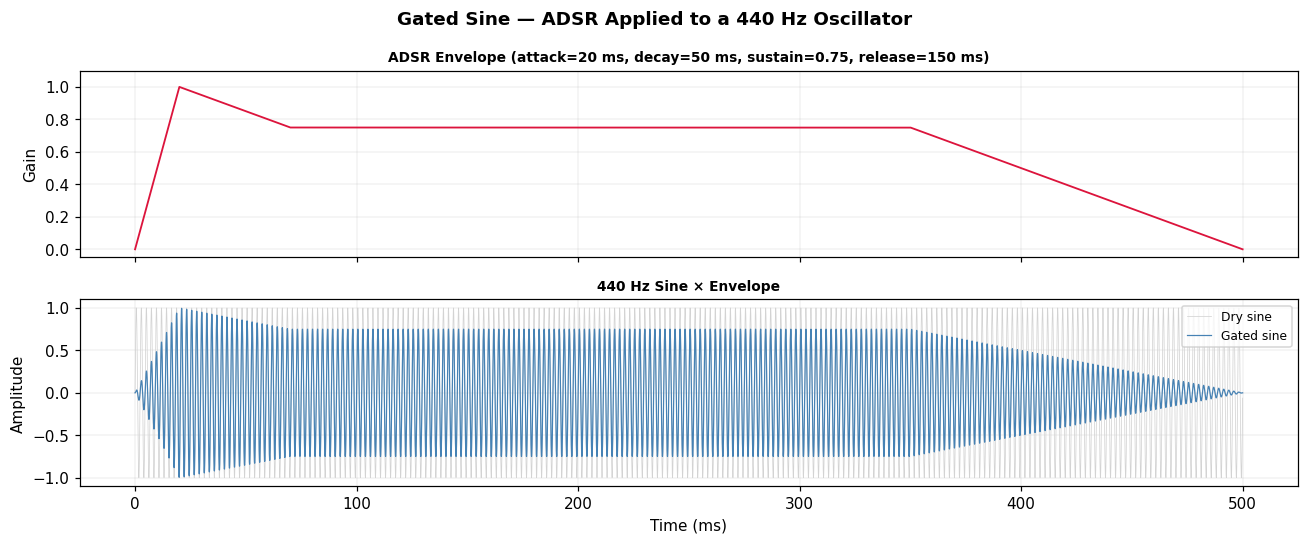

In [4]:
GATE_DUR = 0.5
FREQ = 440.0

t, sine = generate_sine(freq=FREQ, fs=FS, duration=GATE_DUR)
_, gate = generate_adsr(attack=0.02, decay=0.05, sustain=0.75, release=0.15,
                        fs=FS, duration=GATE_DUR)
shaped = sine * gate

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t * 1000, gate, color='crimson', linewidth=1.2)
axes[0].set_title('ADSR Envelope (attack=20 ms, decay=50 ms, sustain=0.75, release=150 ms)',
                  fontsize=9, fontweight='bold')
axes[0].set_ylabel('Gain')
axes[0].set_ylim(-0.05, 1.1)
axes[0].grid(True, linewidth=0.3, alpha=0.5)

axes[1].plot(t * 1000, sine, color='lightgray', linewidth=0.5, label='Dry sine')
axes[1].plot(t * 1000, shaped, color='steelblue', linewidth=0.8, label='Gated sine')
axes[1].set_title(f'440 Hz Sine × Envelope', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].legend(fontsize=8)
axes[1].grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle('Gated Sine — ADSR Applied to a 440 Hz Oscillator', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Segment Verification

Confirm that the three key guarantees hold: peak = 1.0 at attack end, sustain level held exactly, release end = 0.0.

In [5]:
ATTACK, DECAY, SUSTAIN, RELEASE = 0.05, 0.10, 0.65, 0.15
DUR = 0.6

t, env = generate_adsr(attack=ATTACK, decay=DECAY, sustain=SUSTAIN,
                       release=RELEASE, fs=FS, duration=DUR)

n_a = int(ATTACK * FS)
n_d = int(DECAY * FS)
n_r = int(RELEASE * FS)
n_s_start = n_a + n_d
n_s_end = int(DUR * FS) - n_r

peak = env[n_a - 1]
sustain_max_err = np.max(np.abs(env[n_s_start:n_s_end] - SUSTAIN))
release_end = env[-1]

print(f'Peak at attack end:       {peak:.10f}  (expected 1.0)')
print(f'Sustain max deviation:    {sustain_max_err:.2e}  (expected 0.0)')
print(f'Release end value:        {release_end:.2e}  (expected 0.0)')

assert peak == 1.0,                       f'Peak mismatch: {peak}'
assert sustain_max_err < 1e-12,          f'Sustain drift: {sustain_max_err}'
assert abs(release_end) < 1e-12,         f'Release end: {release_end}'
print('All assertions passed.')

Peak at attack end:       1.0000000000  (expected 1.0)
Sustain max deviation:    0.00e+00  (expected 0.0)
Release end value:        0.00e+00  (expected 0.0)
All assertions passed.
